## Trimming and deletion in langgraph - STM

In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

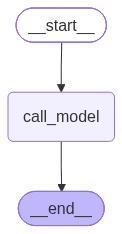

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Suman."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Suman.


'Hi Suman! Nice to meet you. How can I help?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 36
Hi, my name is Suman.
Hi Suman! Nice to meet you. How can I help?
I am learning LangGraph.


'That’s great, Suman — LangGraph is a powerful way to build stateful LLM apps and agent workflows.\n\nIf you want, I can help with any of these:\n- a quick LangGraph overview\n- setting up your first graph\n- nodes, edges, and state\n- conditional routing\n- loops and agent patterns\n- using LangGraph with tools\n- debugging or best practices\n\nIf you’d like, I can also give you a tiny starter example in Python.'

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 146
Hi Suman! Nice to meet you. How can I help?
I am learning LangGraph.
That’s great, Suman — LangGraph is a powerful way to build stateful LLM apps and agent workflows.

If you want, I can help with any of these:
- a quick LangGraph overview
- setting up your first graph
- nodes, edges, and state
- conditional routing
- loops and agent patterns
- using LangGraph with tools
- debugging or best practices

If you’d like, I can also give you a tiny starter example in Python.
Can you explain short term memory?


'Yes.\n\nIn LangGraph, **short-term memory** usually means the **state kept during a single conversation or workflow run** so the graph can remember what happened earlier.\n\n### Simple idea\nIf a user says:\n1. “My name is Suman”\n2. “What is my name?”\n\nthe graph can answer correctly only if it stores that name in its **state**.\n\n### What it is used for\n- keeping conversation context\n- remembering intermediate results\n- passing data from one node to another\n- supporting multi-step workflows\n\n### In LangGraph\nShort-term memory is typically managed through:\n- **graph state**\n- **message history**\n- **checkpointers** for saving state between turns\n\n### Short-term vs long-term\n- **Short-term memory**: temporary, for the current session/thread\n- **Long-term memory**: persistent, saved across sessions, often in a database or vector store\n\n### Tiny example\nA graph may store:\n- user name\n- last question\n- tool result\n- chat messages\n\nSo the next node can use that in

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t know your name from this chat alone. If you want, you can tell me your name and I’ll use it.'

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Suman.
------------------------------------------------------------------------------------------------------------------------
Hi Suman! Nice to meet you. How can I help?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great, Suman — LangGraph is a powerful way to build stateful LLM apps and agent workflows.

If you want, I can help with any of these:
- a quick LangGraph overview
- setting up your first graph
- nodes, edges, and state
- conditional routing
- loops and agent patterns
- using LangGraph with tools
- debugging or best practices

If you’d like, I can also give you a tiny starter example in Python.
------------------------------------------------------------------------------------------------------------------------
Can you explain shor

In [14]:
result

{'messages': [HumanMessage(content='Hi, my name is Suman.', additional_kwargs={}, response_metadata={}, id='b46261ab-0bf5-493d-8aef-e2be73bbe831'),
  AIMessage(content='Hi Suman! Nice to meet you. How can I help?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 14, 'total_tokens': 31, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EF9Vwe9uQdB3aAZ6Cpie9WVeDQvo7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02233-91b6-7792-b589-fac61866fcf3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 17, 'total_tokens': 31, 'input_token_details': {'audi

## Deletion 

In [15]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [16]:
load_dotenv()

True

In [17]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)

In [18]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [20]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [21]:
graph = builder.compile(checkpointer=InMemorySaver())

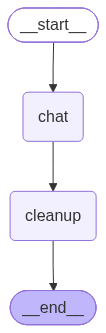

In [22]:
graph

In [27]:
config = {"configurable": {"thread_id": "t2"}}

In [28]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Suman"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='bb81ac9c-fbfe-49d9-96a5-53d332b7f419'),
  AIMessage(content='**LangChain** is a framework for building applications with **LLMs** by providing tools to connect models with:\n- prompts\n- retrieval/search\n- tools/functions\n- memory\n- chains and agents\n\n### In simple terms\nIt helps you build AI apps where the model does more than just generate text. For example:\n- answer questions from your documents\n- call APIs or tools\n- do multi-step reasoning\n- manage chat history\n- build assistants and workflows\n\n### What it’s used for\n- **RAG apps**: retrieve relevant info from your data and answer with it\n- **Agents**: let the model choose tools and actions\n- **Chatbots**: manage conversations\n- **Workflow orchestration**: connect model calls and processing steps\n\n### Main pieces\n- **Models**: OpenAI, Anthropic, local models, etc.\n- **Prompts**: templates for instructing the

In [29]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
